# Au 300 kV - Beam Amplitude Comparison
Simplified comparison of paper reference curves and multislice methods. The paper-extracted KG ODE reference is only available for Beam [0,28].

In [1]:
%matplotlib inline
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from ase.build import bulk
from scipy.interpolate import interp1d
from scipy.special import erfc as scipy_erfc
from time import perf_counter
from abtem.parametrizations import Parametrization

from wide_angle_propagation.wpm import (
    electron_refractive_index,
    energy2wavelength,
    simulate_fresnel_as,
    get_abtem_transmit,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape
    C = np.fft.fft2(psi_xy) / (Nx * Ny)
    if use_fftshift:
        C = np.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return np.abs(C[cy + k, cx + h])
    else:
        return np.abs(C[k % Ny, h % Nx])

## Paper Reference Data
Extracted from Klein-Gordon equation solutions (Figure 3 in doi:10.1016/j.ultramic.2008.08.008)

In [2]:
# Paper reference data for Beam [0,0] - KG Multislice
raw_data_Au_Beam_0_0_Klein_Gordon_MS = """0.06421232876712413, 0.9984732824427482
0.98458904109589, 0.9874045801526719
1.9049657534246576, 0.9599236641221375
2.397260273972603, 0.9431297709923665
3.4460616438356153, 0.9041984732824428
4.216609589041096, 0.8809160305343512
4.880136986301369, 0.867557251908397
5.736301369863013, 0.8641221374045802
6.6138698630137, 0.8725190839694656
7.4486301369863, 0.8858778625954199
8.197773972602743, 0.9022900763358779
8.94691780821918, 0.918320610687023
9.76027397260274, 0.9286259541984734
10.637842465753426, 0.9324427480916031
11.665239726027401, 0.9240458015267177
12.671232876712331, 0.9041984732824428
13.613013698630137, 0.8809160305343513
14.511986301369863, 0.8595419847328245
15.325342465753433, 0.8450381679389314
16.438356164383563, 0.835496183206107
17.529965753424662, 0.8381679389312977
18.728595890410965, 0.8461832061068704
19.58476027397261, 0.8515267175572521
20.71917808219178, 0.8530534351145038
21.72517123287672, 0.8473282442748091
23.073630136986306, 0.8297709923664123
24.14383561643836, 0.8118320610687024
24.807363013698637, 0.8030534351145039
"""

# Paper reference data for Beam [0,28] - KG ODE
raw_data_Au_Beam_0_28_Klein_Gordon_FWD = """0.22062721060899548, 0.00022950819672130918
0.7942772332571906, 0.000852459016393449
1.500467420321705, 0.0018360655737704942
2.339342334788604, 0.0033770491803278707
3.0016335617428496, 0.004622950819672133
4.680202580931187, 0.008819672131147538
5.828562754792266, 0.011508196721311474
7.373218261196406, 0.013475409836065575
8.475824249959047, 0.013901639344262293
9.798479197386307, 0.013770491803278686
10.768593209394673, 0.013901639344262293
11.915700504042945, 0.014885245901639345
12.908872312333159, 0.01639344262295082
14.41020711057142, 0.01940983606557377
15.05035610682242, 0.020524590163934424
16.373974807490292, 0.02170491803278688
18.093647902391076, 0.02183606557377049
19.32792667765346, 0.02144262295081967
21.35669953065218, 0.02219672131147541
22.901379130887335, 0.024196721311475405
24.0047802160735, 0.02570491803278688
24.93111573712666, 0.02626229508196721"""

# Paper reference data for Beam [0,28] - KG Multislice
raw_data_Au_Beam_0_28_Klein_Gordon_MS = """0.06620984763060989, 0.00009836065573769898
0.8162989948053649, 0.0008196721311475447
1.478421564942515, 0.0018360655737704873
2.9133055772400027, 0.0044262295081967246
5.253876697410391, 0.009475409836065572
6.732466919170015, 0.011540983606557375
8.12178949701719, 0.012131147540983607
9.796937192201312, 0.011672131147540982
11.870355914071766, 0.013180327868852457
13.613857807846884, 0.015737704918032787
14.606836865488965, 0.016983606557377046
15.841790268019778, 0.017508196721311473
16.76733069264946, 0.016983606557377046
18.177205308352853, 0.015540983606557375
19.939813610123274, 0.014098360655737704
22.034724029259564, 0.01485245901639344
23.071144264222596, 0.015213114754098356
24.0765157236341217, 0.015081967213114753
24.92234558263702, 0.014327868852459017
"""

def parse_and_interpolate(raw_data):
    data = np.array([[float(val) for val in line.split(',')] for line in raw_data.strip().split('\n')])
    data = data[data[:, 0].argsort()]
    x_extracted = data[:, 0]
    y_extracted = data[:, 1]
    return interp1d(x_extracted, y_extracted, kind='linear', fill_value="extrapolate")

Beam_0_0_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_0_Klein_Gordon_MS)
Beam_0_28_Au_Klein_Gordon_FWD = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_FWD)
Beam_0_28_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_MS)

## Crystal and Simulation Setup

In [3]:
# Simulation parameters
a_central = 4.08  # Angstrom
energy = 300e3  # eV
n_cells_range = range(0, 26)
x = np.array(list(n_cells_range), dtype=float)

# Crystal setup
atoms = bulk("Au", "fcc", a=a_central, cubic=True)
atoms.info['thermal_sigma'] = 0.0
atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

# Potential parameters
lobato_projection = "finite"
lobato_n_slices = 128
coarse_unitcell_gpts = (128, 128, lobato_n_slices)

cell_thickness = atoms.get_cell()[2, 2]
slice_thickness_coarse = cell_thickness / lobato_n_slices

potential_lobato = abtem.Potential(
    atoms,
    gpts=coarse_unitcell_gpts[:2],
    slice_thickness=slice_thickness_coarse,
    projection=lobato_projection,
    parametrization="lobato"
)

wavelength = energy2wavelength(energy)
k0 = 2 * np.pi / wavelength

print(f"Gold lattice parameter: {a_central} Å")
print(f"Energy: {energy/1000:.0f} keV")
print(f"Wavelength: {wavelength:.6f} Å")

Gold lattice parameter: 4.08 Å
Energy: 300 keV
Wavelength: 0.019687 Å


## Run Multislice Simulations

In [4]:
# Probe setup and get transmission functions
probe = abtem.PlaneWave(energy=energy)
probe.grid.match(potential_lobato)
probe_array = probe.build(lazy=False).array

# Convert probe to JAX array
psi0 = jnp.array(cupy.asnumpy(probe_array))

# Build potential array as JAX
pot_array = jnp.array(cupy.asnumpy(potential_lobato.build(lazy=False).array / slice_thickness_coarse))
sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))

# Create propagation kernels
fk = jnp.array(
    fresnel_propagation_kernel(128, 128, sampling, z=slice_thickness_coarse, energy=energy)
)
ak = jnp.array(
    angular_spectrum_propagation_kernel(128, 128, sampling, z=slice_thickness_coarse, energy=energy)
)

results = {}

# Fresnel Multislice Simulation
print("\nRunning Fresnel Multislice...")
t0 = perf_counter()

measurements_multislice_0_0 = []
measurements_multislice_0_28 = []

psi = psi0.copy()
for i, n_cell in enumerate(n_cells_range):
    if i > 0:
        psi, _, _ = simulate_fresnel_as(pot_array, psi, fk, slice_thickness_coarse, energy)
        psi = jnp.array(psi)
    psi_np = np.asarray(psi)
    measurements_multislice_0_0.append(beam_amplitude_normalized(psi_np, 0, 0))
    measurements_multislice_0_28.append(beam_amplitude_normalized(psi_np, 0, 28))

measurements_multislice_0_0 = np.array(measurements_multislice_0_0)
measurements_multislice_0_28 = np.array(measurements_multislice_0_28)
results['ms_00'] = measurements_multislice_0_0
results['ms_028'] = measurements_multislice_0_28

print(f"  Completed in {perf_counter() - t0:.1f}s")
print(f"  [0,0] @ 25 cells: {measurements_multislice_0_0[-1]:.6f}")
print(f"  [0,28] @ 25 cells: {measurements_multislice_0_28[-1]:.6f}")


Running Fresnel Multislice...
  Completed in 10.2s
  [0,0] @ 25 cells: 0.802639
  [0,28] @ 25 cells: 0.012960


In [5]:
# Angular Spectrum Multislice Simulation
print("\nRunning Angular Spectrum Multislice...")
t0 = perf_counter()

measurements_as_0_0 = []
measurements_as_0_28 = []

psi = psi0.copy()
for i, n_cell in enumerate(n_cells_range):
    if i > 0:
        psi, _, _ = simulate_fresnel_as(pot_array, psi, ak, slice_thickness_coarse, energy)
        psi = jnp.array(psi)
    psi_np = np.asarray(psi)
    measurements_as_0_0.append(beam_amplitude_normalized(psi_np, 0, 0))
    measurements_as_0_28.append(beam_amplitude_normalized(psi_np, 0, 28))

measurements_as_0_0 = np.array(measurements_as_0_0)
measurements_as_0_28 = np.array(measurements_as_0_28)
results['as_00'] = measurements_as_0_0
results['as_028'] = measurements_as_0_28

print(f"  Completed in {perf_counter() - t0:.1f}s")
print(f"  [0,0] @ 25 cells: {measurements_as_0_0[-1]:.6f}")
print(f"  [0,28] @ 25 cells: {measurements_as_0_28[-1]:.6f}")


Running Angular Spectrum Multislice...
  Completed in 8.8s
  [0,0] @ 25 cells: 0.800810
  [0,28] @ 25 cells: 0.023650


## Generate Comparison Plot

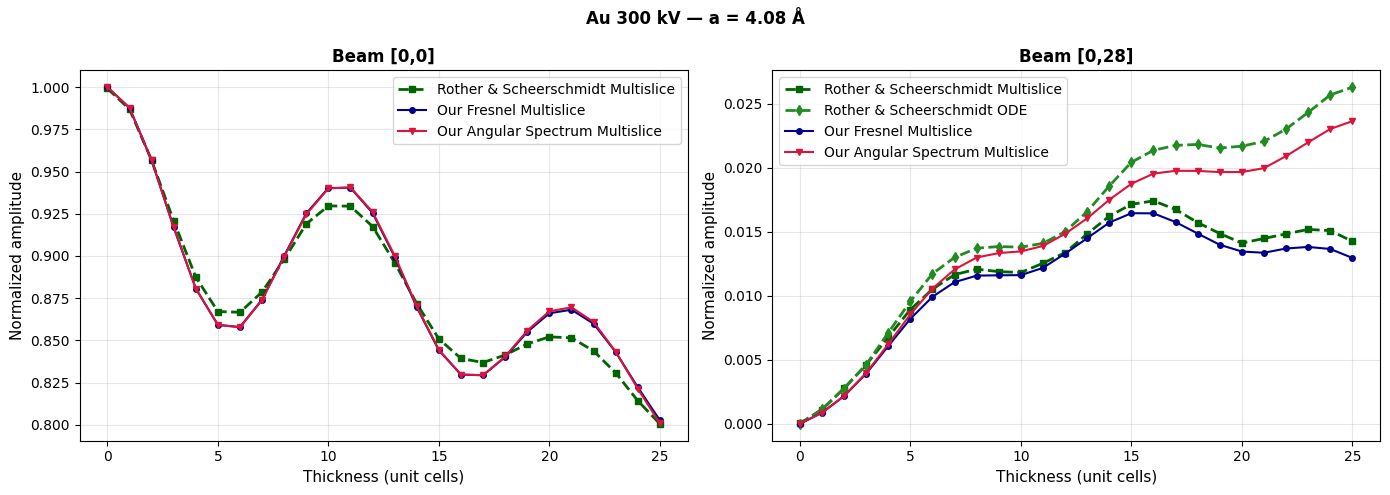


Figure saved as 'Au_beam_comparison.png'
Note: the paper-extracted KG ODE reference is only available for Beam [0,28].


: 

In [ ]:
# Paper reference curves
measurements_multislice_paper_0_0 = Beam_0_0_Au_Klein_Gordon_MS(x)
measurements_ms_paper_0_28 = Beam_0_28_Au_Klein_Gordon_MS(x)
measurements_fwd_ode_paper_0_28 = Beam_0_28_Au_Klein_Gordon_FWD(x)

# Create figure with both beams
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Beam [0,0] Plot
ax1.plot(x, measurements_multislice_paper_0_0, "s--", label="Rother & Scheerschmidt Multislice", color="darkgreen", ms=5, linewidth=2)
ax1.plot(x, measurements_multislice_0_0, "o-", label="Our Fresnel Multislice", color="darkblue", ms=4, linewidth=1.5)
ax1.plot(x, measurements_as_0_0, "v-", label="Our Angular Spectrum Multislice", color="crimson", ms=4, linewidth=1.5)
ax1.set_xlabel("Thickness (unit cells)", fontsize=11)
ax1.set_ylabel("Normalized amplitude", fontsize=11)
ax1.set_title("Beam [0,0]", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='best')

# Beam [0,28] Plot
ax2.plot(x, measurements_ms_paper_0_28, "s--", label="Rother & Scheerschmidt Multislice", color="darkgreen", ms=5, linewidth=2)
ax2.plot(x, measurements_fwd_ode_paper_0_28, "d--", label="Rother & Scheerschmidt ODE", color="forestgreen", ms=5, linewidth=2)
ax2.plot(x, measurements_multislice_0_28, "o-", label="Our Fresnel Multislice", color="darkblue", ms=4, linewidth=1.5)
ax2.plot(x, measurements_as_0_28, "v-", label="Our Angular Spectrum Multislice", color="crimson", ms=4, linewidth=1.5)
ax2.set_xlabel("Thickness (unit cells)", fontsize=11)
ax2.set_ylabel("Normalized amplitude", fontsize=11)
ax2.set_title("Beam [0,28]", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc='best')

fig.suptitle(f"Au 300 kV — a = {a_central} Å", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Save figure
fig.savefig("Au_beam_comparison.png", dpi=300, bbox_inches="tight")
print("\nFigure saved as 'Au_beam_comparison.png'")
print("Note: the paper-extracted KG ODE reference is only available for Beam [0,28].")

## Error Analysis

In [7]:
def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

print("\n" + "=" * 70)
print("Root Mean Square Error (RMSE) vs Paper Reference")
print("=" * 70)
print(f"{'Method':<25s} {'[0,0] vs KG MS':>16s} {'[0,28] vs KG ODE':>18s}")
print("-" * 61)

methods = {
    "Fresnel MS": (measurements_multislice_0_0, measurements_multislice_0_28),
    "Angular Spectrum MS": (measurements_as_0_0, measurements_as_0_28),
}

for name, (data_00, data_028) in methods.items():
    r00 = curve_rmse(data_00, measurements_multislice_paper_0_0)
    r028 = curve_rmse(data_028, measurements_fwd_ode_paper_0_28)
    print(f"{name:<25s} {r00:>16.6f} {r028:>18.6f}")

print("\nBeam [0,0] has no paper-extracted KG ODE reference in this notebook source.")


Root Mean Square Error (RMSE) vs Paper Reference
Method                      [0,0] vs KG MS   [0,28] vs KG ODE
-------------------------------------------------------------
Fresnel MS                        0.008264           0.005851
Angular Spectrum MS               0.008539           0.001490

Beam [0,0] has no paper-extracted KG ODE reference in this notebook source.
